In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

In [2]:
df = pd.read_csv("Air Traffic Data Cor Updated.csv",parse_dates=['Date'],index_col='Date')
df.head()

,domestic passengers,international passenegrs,domestic freight(in tonne),international freight(in tonne),GDP (in dollars),Jet Fuel Price per Gallon,Inflation Rate,Unemployement Rate
Date,,,,,,,,
2009-01-01,3288004,885435,20832,11675,1.341888e+12,71.75,10.88,7.66
2009-01-02,3293220,757168,18645,12482,1.341888e+12,61.97,10.88,7.66
2009-01-03,3122400,848046,23046,15359,1.341888e+12,65.01,10.88,7.66
2009-01-04,3266686,861715,21623,14512,1.341888e+12,68.55,10.88,7.66
2009-01-05,3883887,898410,19534,14586,1.341888e+12,72.22,10.88,7.66


In [4]:
targets=['domestic passengers', 'international passenegrs',
           'domestic freight(in tonne)', 'international freight(in tonne)']

exogs = ['GDP (in dollars)', 'Jet Fuel Price per Gallon',
        'Inflation Rate ', 'Unemployement Rate']

In [6]:
features = targets + exogs

Scaling using MinMaxScaler

In [9]:
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df[features])
scaled_df = pd.DataFrame(scaled_data, index=df.index, columns=features)

Sequence Generation of the Data

In [10]:
def create_multivariate_sequences(data, target_cols, seq_length=12):
    X, y = [], []
    target_idx = [data.columns.get_loc(col) for col in target_cols]

    values = data.values
    for i in range(len(values) - seq_length):
        # input: past `seq_length` months of all variables
        X.append(values[i:i+seq_length])  
        
        # output: next-step of only targets
        y.append(values[i+seq_length, target_idx])  
    
    return np.array(X), np.array(y)

SEQ_LEN = 12
X, y = create_multivariate_sequences(scaled_df, targets, SEQ_LEN)

print("X shape:", X.shape)   # (samples, 12, num_features)
print("y shape:", y.shape)   # (samples, num_targets)


X shape: (180, 12, 8)
y shape: (180, 4)


Train-Test-Split

In [11]:
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]


Building LSTM model

In [12]:
model = Sequential()
model.add(LSTM(128, activation='tanh', return_sequences=True, input_shape=(SEQ_LEN, len(features))))
model.add(Dropout(0.2))
model.add(LSTM(64, activation='tanh'))
model.add(Dropout(0.2))
model.add(Dense(len(targets)))  # predict 4 target variables

model.compile(optimizer='adam', loss='mse')
model.summary()


C:\Users\abhij\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 12, 128)        │        70,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 119,812 (468.02 KB)

 Trainable params: 119,812 (468.02 KB)

 Non-trainable params: 0 (0.00 B)

Model Training

In [ ]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=16,
    verbose=1
)

Epoch 1/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step - loss: 0.1088 - val_loss: 0.0378
Epoch 2/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0379 - val_loss: 0.0634
Epoch 3/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0275 - val_loss: 0.0215
Epoch 4/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0229 - val_loss: 0.0474
Epoch 5/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0209 - val_loss: 0.0420
Epoch 6/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0210 - val_loss: 0.0427
Epoch 7/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0207 - val_loss: 0.0562
Epoch 8/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0186 - val_loss: 0.0610
Epoch 9/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0147 - val_loss: 0.0972
Epoch 10/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0159 - val_loss: 0.0959
Epoch 11/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0163 - val_loss: 0.0992
Epoch 12/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0150 - val_loss: 0.1379
E

In [14]:
y_pred = model.predict(X_test)

# Inverse scaling
scaled_full = scaler.inverse_transform(scaled_df[features])
scaler_targets = MinMaxScaler()
scaler_targets.fit(df[targets])   # separate scaler for targets

y_test_inv = scaler_targets.inverse_transform(y_test)
y_pred_inv = scaler_targets.inverse_transform(y_pred)

# Evaluation metrics



2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 310ms/step


In [15]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

for i, col in enumerate(targets):
    rmse = np.sqrt(mean_squared_error(y_test_inv[:, i], y_pred_inv[:, i]))
    mae = mean_absolute_error(y_test_inv[:, i], y_pred_inv[:, i])
    r2 = r2_score(y_test_inv[:, i], y_pred_inv[:, i])
    print(f"{col}: RMSE={rmse:.2f}, MAE={mae:.2f}, R²={r2:.3f}")

domestic passengers: RMSE=6032430.60, MAE=5291574.66, R²=-11.402
international passenegrs: RMSE=2022968.29, MAE=1898727.00, R²=-14.108
domestic freight(in tonne): RMSE=58188.54, MAE=52116.63, R²=-127.157
international freight(in tonne): RMSE=29685.60, MAE=26152.39, R²=-40.322


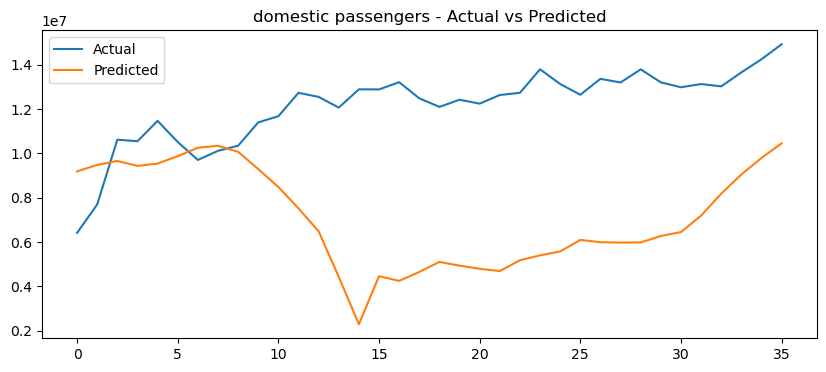

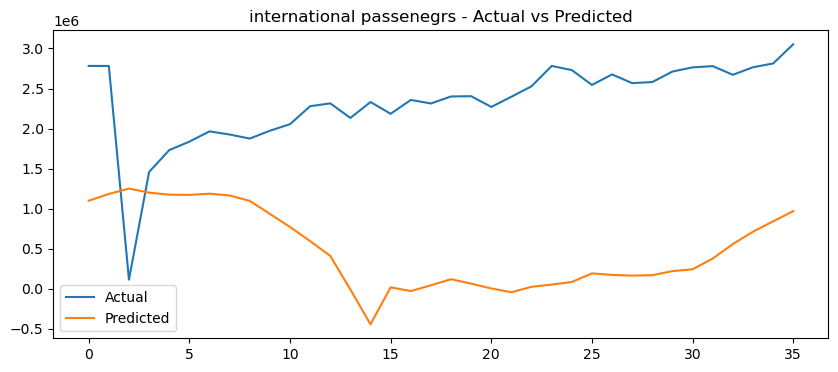

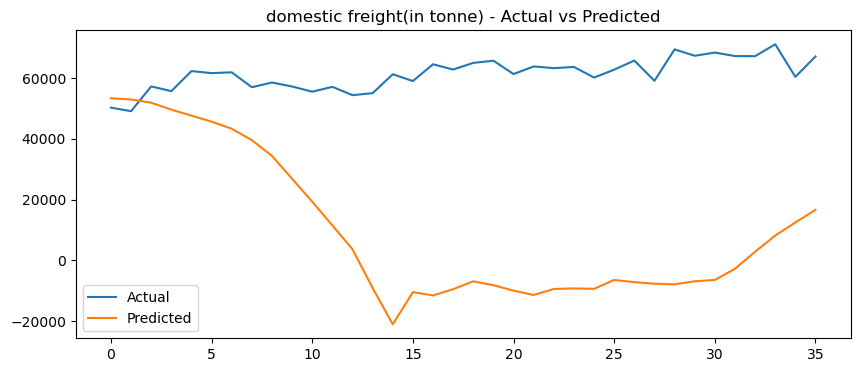

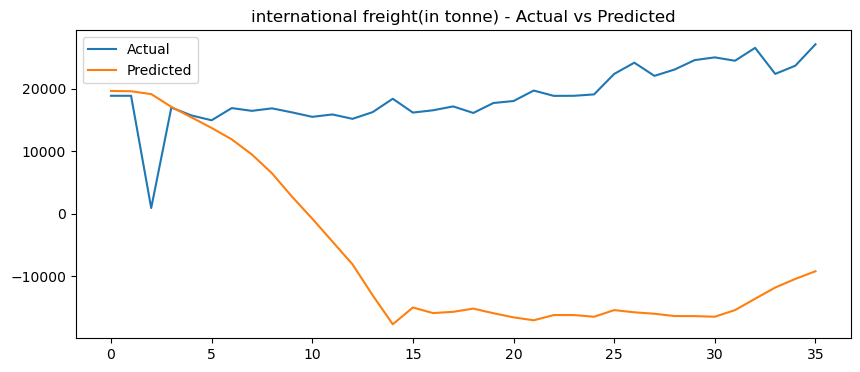

In [16]:
import matplotlib.pyplot as plt

for i, col in enumerate(targets):
    plt.figure(figsize=(10,4))
    plt.plot(y_test_inv[:, i], label="Actual")
    plt.plot(y_pred_inv[:, i], label="Predicted")
    plt.title(f"{col} - Actual vs Predicted")
    plt.legend()
    plt.show()


Seperate Scalers for targets and exogs

In [ ]:
# Scale exogenous features
scaler_exog = MinMaxScaler()
scaled_exog = scaler_exog.fit_transform(df[exogs])

# Scale targets
scaler_targets = MinMaxScaler()
scaled_targets = scaler_targets.fit_transform(df[targets])

# Recombine
scaled_df = pd.DataFrame(
    np.hstack([scaled_targets, scaled_exog]),
    index=df.index,
    columns=targets + exogs
)